In [1]:
"""Accuracy by overflow style and token budget for Qwen3-8B."""

import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

In [ ]:
# --- configuration ---

# all runs (baseline + overflow) are stored in one file per model
RESULTS_PATH = Path("../../output/qwen3-8b.json")
FIGURES_DIR = Path("../../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# benchmarks to plot: display name → key prefix in results files
BENCHMARKS: dict[str, str] = {
    "EvalPlus": "code/evalplus_greedy",
    "LiveCodeBench": "code/livecodebench_greedy",
    "BigCodeBench": "code/bigcodebench_greedy",
    "CRUXEval-I": "crux/cruxeval_i_greedy",
    "CRUXEval-O": "crux/cruxeval_o_greedy",
    "GSM8K": "math/gsm8k_greedy",
    "GPQA": "reasoning/gpqa_greedy",
}

# overflow methods tested (order determines left-to-right grouping in the chart)
STYLES: list[str] = ["base", "truncated", "formal", "human"]
STYLE_LABELS: dict[str, str] = {
    "base": "Base",
    "truncated": "Truncated",
    "formal": "Formal",
    "human": "Human",
}

# token budget levels tested
MAX_TOKENS: list[int] = [2048, 4096, 8192, 16384]
TOKEN_LABELS: dict[int, str] = {
    2048: "2K",
    4096: "4K",
    8192: "8K",
    16384: "16K",
}

# colours for each token budget, lightest to darkest blue
TOKEN_COLOURS: dict[int, str] = {
    2048: "#BBDEFB",
    4096: "#64B5F6",
    8192: "#1976D2",
    16384: "#0D47A1",
}
BASELINE_COLOUR = "#78909C"  # blue-grey for the unconstrained baseline

In [3]:
def load_data(
    results_path: Path,
) -> dict[str, dict]:
    """Load pass@1 accuracy and confidence intervals for all benchmarks.

    Reads the results file which holds both baseline and overflow entries.
    CI errors are converted to asymmetric deviations from the point estimate
    so they can be passed directly to matplotlib's yerr parameter.

    Returns a nested dict:
        benchmark_label → {
            "baseline": (value, lower_err, upper_err),
            "styles": {style: {max_tokens: (value, lower_err, upper_err)}},
        }
    """
    with open(results_path) as f:
        results = json.load(f)

    data: dict[str, dict] = {}
    for label, prefix in BENCHMARKS.items():
        # unconstrained baseline: plain greedy, run with --baseline flag (run_name='baseline')
        bl = results[prefix + "_baseline"]
        bl_val = bl["pass_at_1"]
        bl_ci = bl["pass_at_1_ci"]
        bl_entry = (
            bl_val,
            bl_val - bl_ci[0],  # lower error bar (distance below point estimate)
            bl_ci[1] - bl_val,  # upper error bar (distance above point estimate)
        )

        # overflow results for every style × token-budget combination
        styles: dict[str, dict[int, tuple[float, float, float]]] = {}
        for style in STYLES:
            styles[style] = {}
            for mt in MAX_TOKENS:
                key = f"{prefix}_mt{mt}_{style}"
                entry = results[key]
                val = entry["pass_at_1"]
                ci = entry["pass_at_1_ci"]
                styles[style][mt] = (
                    val,
                    val - ci[0],
                    ci[1] - val,
                )

        data[label] = {
            "baseline": bl_entry,
            "styles": styles,
        }

    return data

In [4]:
def plot_accuracy_by_style(
    data: dict[str, dict],
    save_path: Path,
) -> None:
    """Plot a vertical stack of grouped bar charts, one per benchmark.

    Each chart shows the unconstrained baseline as a single bar, followed by
    four groups of bars — one group per overflow style — where each bar within
    a group represents a different max_tokens budget. Error bars show the 95%
    confidence intervals from pass_at_1_ci. Saves the combined figure as a PNG.
    """
    n_benchmarks = len(data)
    bar_width = 0.6
    # horizontal gap (in x-axis units) between the baseline and the first group,
    # and between successive style groups
    group_gap = 1.0

    n_tokens = len(MAX_TOKENS)  # 4 bars per group
    group_span = n_tokens * bar_width  # total width of one style group

    # x positions: baseline at 0, then each style group follows after a gap
    baseline_x = 0.0
    group_starts: list[float] = []
    for i in range(len(STYLES)):
        if i == 0:
            # first group begins after the baseline bar's right edge plus a gap
            group_starts.append(baseline_x + bar_width / 2 + group_gap)
        else:
            group_starts.append(group_starts[-1] + group_span + group_gap)

    # x-tick positions: one at the baseline and one centred on each style group
    tick_positions: list[float] = [baseline_x]
    tick_labels_list: list[str] = ["Baseline"]
    for i, style in enumerate(STYLES):
        centre = group_starts[i] + (n_tokens - 1) * bar_width / 2
        tick_positions.append(centre)
        tick_labels_list.append(STYLE_LABELS[style])

    fig, axes = plt.subplots(
        nrows=n_benchmarks,
        ncols=1,
        figsize=(12, 4 * n_benchmarks),
    )
    fig.suptitle(
        "Accuracy by Overflow Style and Token Budget — Qwen3-8B",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )

    for ax, (benchmark_label, bench_data) in zip(axes, data.items()):
        # draw the baseline bar (unconstrained greedy)
        bl_val, bl_lo, bl_hi = bench_data["baseline"]
        ax.bar(
            baseline_x,
            bl_val,
            width=bar_width,
            color=BASELINE_COLOUR,
            yerr=[[bl_lo], [bl_hi]],
            capsize=3,
            error_kw={"linewidth": 1},
            zorder=3,
        )

        # draw one group of bars per overflow style
        for i, style in enumerate(STYLES):
            for j, mt in enumerate(MAX_TOKENS):
                val, lo, hi = bench_data["styles"][style][mt]
                x = group_starts[i] + j * bar_width
                ax.bar(
                    x,
                    val,
                    width=bar_width,
                    color=TOKEN_COLOURS[mt],
                    yerr=[[lo], [hi]],
                    capsize=3,
                    error_kw={"linewidth": 1},
                    zorder=3,
                )

        # dashed vertical line separating the baseline from the style groups
        separator_x = baseline_x + bar_width / 2 + group_gap / 2
        ax.axvline(
            x=separator_x,
            color="#BDBDBD",
            linewidth=0.8,
            linestyle="--",
        )

        ax.set_title(benchmark_label, fontsize=11, fontweight="bold")
        ax.set_ylabel("pass@1")
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels_list)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7, zorder=0)
        ax.set_axisbelow(True)

        # start the y-axis just below the lowest value so differences are visible
        all_vals: list[float] = [bl_val] + [
            bench_data["styles"][s][mt][0] for s in STYLES for mt in MAX_TOKENS
        ]
        y_min = max(0.0, min(all_vals) - 0.05)
        y_max = min(1.0, max(all_vals) + 0.05)
        ax.set_ylim(y_min, y_max)

        # remove top and right spines for a cleaner look
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # shared legend for token budget colours, drawn below all subplots
    legend_handles = [
        mpatches.Patch(
            color=TOKEN_COLOURS[mt],
            label=f"{TOKEN_LABELS[mt]} tokens",
        )
        for mt in MAX_TOKENS
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(MAX_TOKENS),
        bbox_to_anchor=(0.5, -0.02),
        frameon=False,
        fontsize=10,
    )

    plt.tight_layout()
    fig.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )
    print(f"saved → {save_path}")
    plt.show()

saved → ../../figures/overflow/02/accuracy_by_style.png


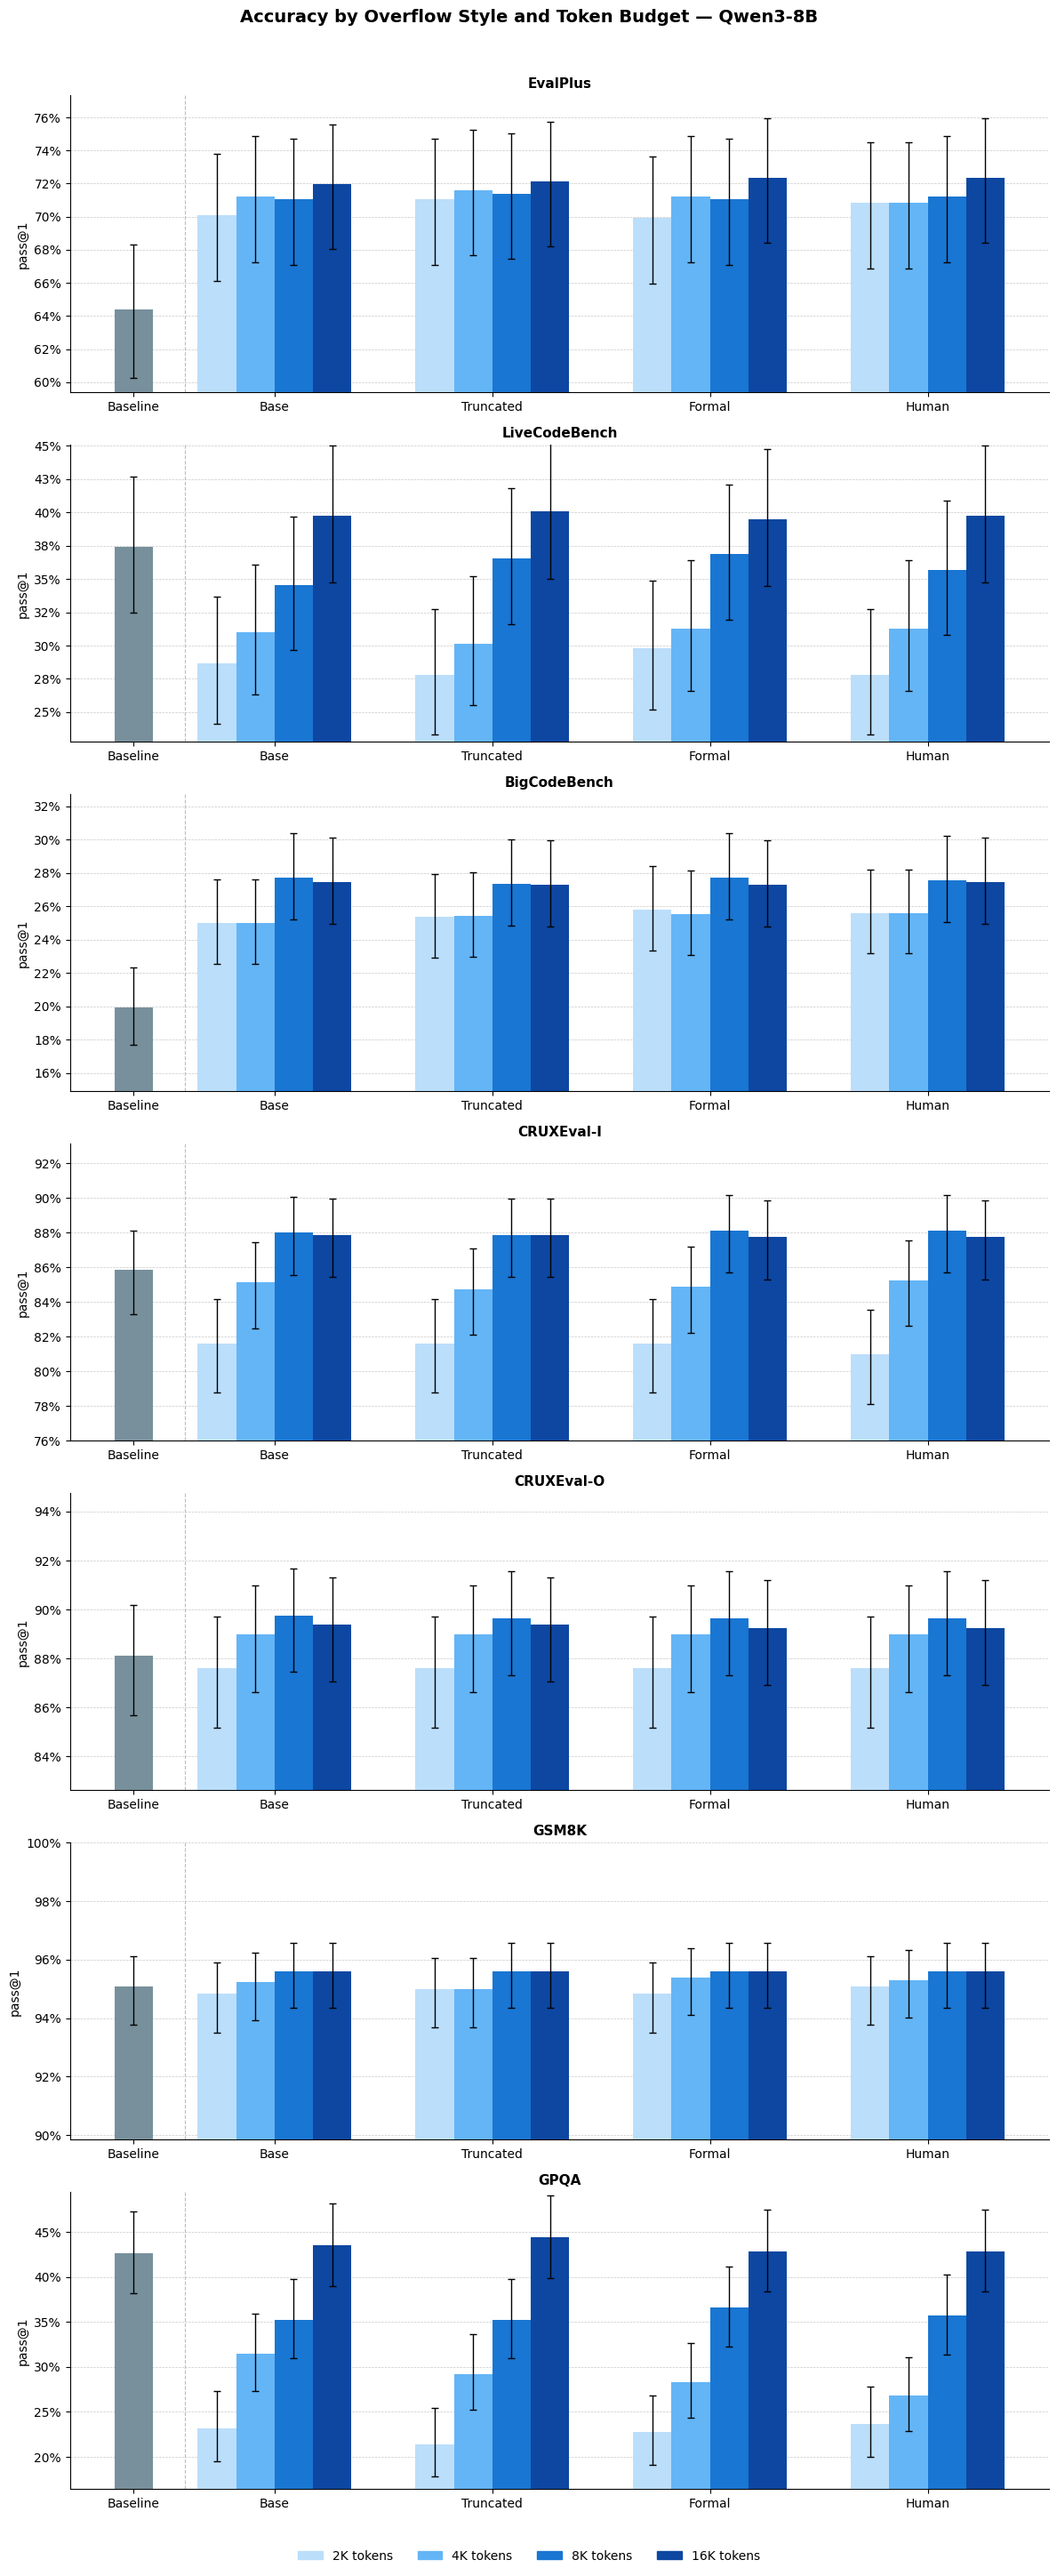

In [ ]:
data = load_data(
    results_path=RESULTS_PATH,
)
plot_accuracy_by_style(
    data=data,
    save_path=FIGURES_DIR / "03_accuracy_by_style.png",
)